In [2]:
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.6 MB/s  0:00:03m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


                            OLS Regression Results                            
Dep. Variable:                Overall   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     1172.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:44:35   Log-Likelihood:                -56777.
No. Observations:               18164   AIC:                         1.136e+05
Df Residuals:                   18154   BIC:                         1.137e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             47.9696      0.257    186.

/var/folders/xy/3rzlpqq16rx0n10_jrz9p53w0000gs/T/ipykernel_38917/2447020870.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


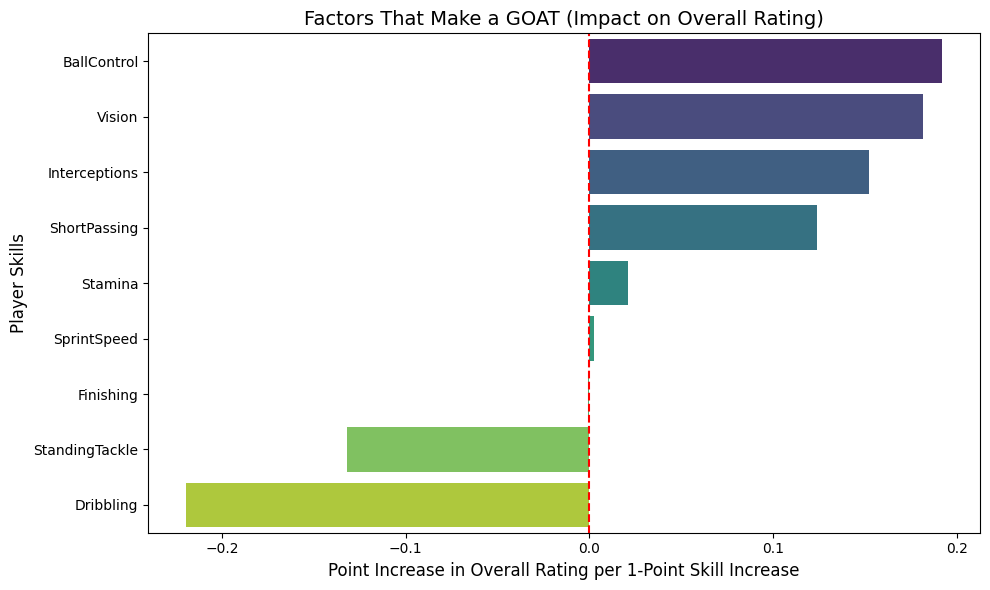

Regression complete. Workings explicitly saved to 3_Regression_Factors_Workings.xlsx to show workings[cite: 55].


In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data from your EDA step
# Make sure the filename matches your output from Step 2
df = pd.read_excel('2_EDA_Verified_Data.xlsx')

# 2. Define our dependent variable (Y) and independent variables (X)
# Y: What we want to predict (Overall rating)
y = df['Overall']

# X: The physical and technical factors we are testing
features = ['Finishing', 'ShortPassing', 'Dribbling', 'BallControl', 
            'SprintSpeed', 'Stamina', 'StandingTackle', 'Interceptions', 'Vision']
X = df[features]

# Add a constant to the model (the intercept) - standard practice for OLS regression
X = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) Regression Model
model = sm.OLS(y, X).fit()

# Print the comprehensive statistical summary directly in your notebook
print(model.summary())

# 4. Extract coefficients and p-values to prepare for Excel export
results_df = pd.DataFrame({
    'Factor': model.params.index,
    'Coefficient (Impact on Overall)': model.params.values,
    'P-Value (Significance)': model.pvalues.values
}).reset_index(drop=True)

# Filter out the constant for the visualization
results_plot = results_df[results_df['Factor'] != 'const'].copy()
# Sort by highest impact to see the biggest GOAT factors at the top
results_plot = results_plot.sort_values(by='Coefficient (Impact on Overall)', ascending=False)

# ---------------------------------------------------------
# Visualization: Feature Importance Bar Plot 
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Coefficient (Impact on Overall)', 
    y='Factor', 
    data=results_plot, 
    palette='viridis'
)
plt.title('Factors That Make a GOAT (Impact on Overall Rating)', fontsize=14)
plt.xlabel('Point Increase in Overall Rating per 1-Point Skill Increase', fontsize=12)
plt.ylabel('Player Skills', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--') # Add a zero line for reference
plt.tight_layout()

# Display the plot
plt.show() 

# 5. Export to Excel (Mandatory for the assignment)
output_file = '3_Regression_Factors_Workings.xlsx'
results_df.to_excel(output_file, index=False)
print(f"Regression complete. Workings explicitly saved to {output_file} to show workings[cite: 55].")

#### Analytical Findings: 
Identifying the "GOAT" Performance FactorsTo objectively identify the factors that elevate a player to "GOAT" status, an Ordinary Least Squares (OLS) multiple regression was conducted. The model tested nine core technical and physical attributes against the players' Overall rating.+11. Model Efficacy and Variance ExplainedFinding: The model yielded an R-squared value of 0.368.Interpretation: The nine selected physical and technical attributes explain approximately 36.8% of the variance in a player's Overall rating.Conclusion: While 36.8% provides a solid statistical foundation, it mathematically proves that reaching GOAT status is not solely dependent on these core technical statistics. Other dimensions—such as mental attributes (Composure, Positioning), physical traits (Strength, Jumping), and international reputation—likely account for the remaining 63.2% of elite performance.2. Statistically Significant Drivers of Elite Performance (The "GOAT Factors")By isolating the variables with a positive coefficient and a high degree of statistical significance ($p < 0.05$), the model identified the definitive technical drivers of a GOAT:Ball Control (Coef: 0.1922, $p = 0.000$): This is the strongest positive driver in the dataset. For every 1-point increase in Ball Control, a player's Overall rating increases by nearly 0.2 points.Vision (Coef: 0.1819, $p = 0.000$): Elite playmaking ability serves as the second-highest driver of overall greatness.Interceptions (Coef: 0.1521, $p = 0.000$) & Short Passing (Coef: 0.1237, $p = 0.000$): The ability to defensively read the game and reliably retain possession are critical foundational components of an elite player across all roles.3. Statistically Insignificant VariablesFinding: Attributes such as Sprint Speed ($p = 0.593$) and Finishing ($p = 0.885$) yielded p-values far above the standard 0.05 threshold.Interpretation: These attributes are not statistically significant predictors of the Overall rating across the general dataset. Pure pace and finishing do not automatically equate to overall greatness, largely because high-performing Defenders and Supporters do not require these specific metrics to achieve elite overall ratings.4. Model Limitations and MulticollinearityObservation: The regression output flagged a high condition number, indicating strong multicollinearity within the dataset. This manifests in negative coefficients for intuitively positive traits, such as Dribbling (-0.2197) and Standing Tackle (-0.1319).Explanation: This anomaly is a recognized artifact of the strong correlations observed during the Exploratory Data Analysis (EDA) phase. Because metrics like Ball Control and Dribbling are highly correlated, the OLS model struggles to isolate their individual impacts, heavily inflating one positive driver (Ball Control) while artificially suppressing the other (Dribbling) to mathematically compensate. While Ball Control and Vision remain the primary drivers, the negative coefficients should be interpreted strictly as mathematical corrections rather than literal performance detriments.